# Tuned Lens

This notebook keeps the original tuned-lens setup, but changes the output to better match the project goal: show the input prompt, then for each inspected layer show the predicted next token and its probability.

## 1. Load model and data

We use a frozen `pythia-14M` model and a small subset of `pile-10k` text. The tuned lens is trained to match the model's final next-token distribution.

In [ ]:
from IPython.display import Markdown, display
from transformer_lens import HookedTransformer
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

model: HookedTransformer = HookedTransformer.from_pretrained("pythia-14M")

# dataset: pile-10k from neel nanda
df = pd.read_parquet("hf://datasets/NeelNanda/pile-10k/data/train-00000-of-00001-4746b8785c874cc7.parquet")

# device
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
# freeze base model
model.eval()
for p in model.parameters():
    p.requires_grad = False

## 2. Choose layers to inspect

For this small model, it is still readable to inspect all layers. That gives a clearer depth-by-depth trajectory than a sparse subset.

In [ ]:
# use all layers for this small model so the trajectory is easy to read
layers = list(range(model.cfg.n_layers))
hook_names = [f"blocks.{layer}.hook_resid_post" for layer in layers]
d_model = model.cfg.d_model

In [27]:
# one affine translator per selected layer, each initialized to identity
lenses = {}
for layer in layers:
    lens = nn.Linear(d_model, d_model).to(device)
    with torch.no_grad():
        lens.weight.copy_(torch.eye(d_model, device=device))
        lens.bias.zero_()
    lenses[layer] = lens

opt = torch.optim.AdamW(
    [p for lens in lenses.values() for p in lens.parameters()],
    lr=1e-3,
)

texts = df["text"][:2000].tolist()
seq_len = 64
steps = 2001
loss_history = []

## 3. Train the tuned-lens probes

This keeps the same idea as the original notebook: each probe is trained with KL divergence to match the final-layer next-token distribution.

In [28]:
for step in range(steps):
    text = texts[step % len(texts)]
    tokens = model.to_tokens(text, prepend_bos=True)[:, :seq_len].to(device)

    if tokens.shape[1] < 2:
        continue

    with torch.no_grad():
        final_logits, cache = model.run_with_cache(
            tokens,
            names_filter=lambda n: n in hook_names,
        )
        teacher = F.softmax(final_logits[:, :-1, :], dim=-1)

    loss = torch.tensor(0.0, device=device)
    for layer in layers:
        hook_name = f"blocks.{layer}.hook_resid_post"
        resid = cache[hook_name]
        lens_logits = model.unembed(model.ln_final(lenses[layer](resid)))
        loss = loss + F.kl_div(
            F.log_softmax(lens_logits[:, :-1, :], dim=-1),
            teacher,
            reduction="batchmean",
        )

    loss = loss / len(layers)
    opt.zero_grad()
    loss.backward()
    opt.step()
    loss_history.append(float(loss.detach().cpu()))

    if step % 100 == 0:
        print(step, float(loss))

0 283.0984191894531
100 135.2365264892578
200 139.56993103027344
300 110.4346694946289
400 115.33025360107422
500 107.26699829101562
600 131.57444763183594
700 48.250606536865234
800 82.4509048461914
900 114.76290893554688
1000 100.18844604492188
1100 109.03539276123047
1200 79.938720703125
1300 111.56378173828125
1400 70.60668182373047
1500 81.09395599365234
1600 96.12066650390625
1700 88.38568115234375
1800 111.03478240966797
1900 97.0307388305664
2000 53.278263092041016


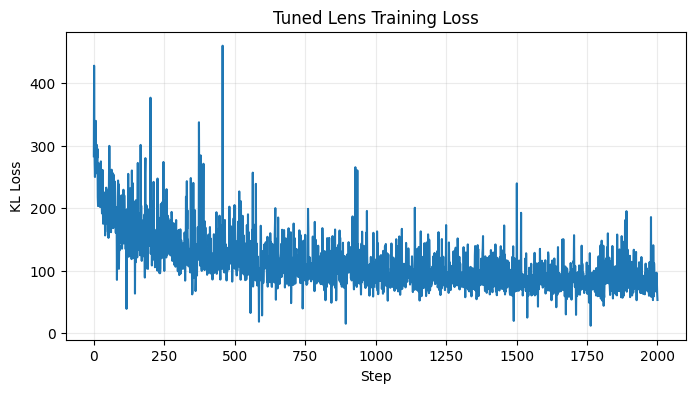

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Tuned Lens Training Loss")
plt.xlabel("Step")
plt.ylabel("KL Loss")
plt.grid(alpha=0.25)
plt.show()

## 4. Prompt-level results

The main deliverable is a readable prompt summary: input sentence at the top, then one row per layer with the predicted token and its probability. The plot below is a row-by-row visual rather than a bar chart.

### Input prompt
`The sky is blue and the grass is`

layer,predicted_token,probability
0,a,0.189000
1,a,0.077000
2,a,0.108000
3,blue,0.351000
4,blue,0.300000
5,blue,0.101000
final,blue,0.138000


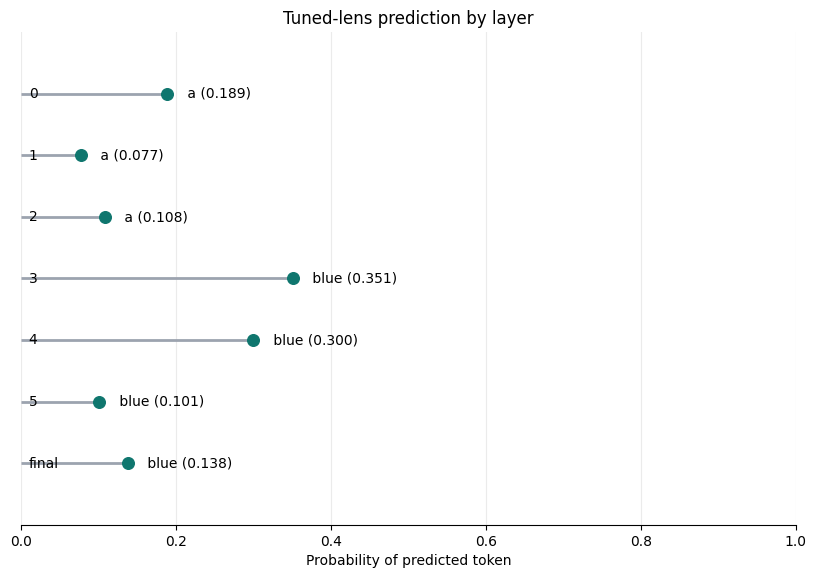

In [30]:
prompt = "The sky is blue and the grass is"
tokens = model.to_tokens(prompt, prepend_bos=True).to(device)

with torch.no_grad():
    final_logits, cache = model.run_with_cache(
        tokens,
        names_filter=lambda n: n in hook_names,
    )

rows = []
for layer in layers:
    hook_name = f"blocks.{layer}.hook_resid_post"
    logits = model.unembed(model.ln_final(lenses[layer](cache[hook_name])))
    probs = F.softmax(logits, dim=-1)[0, -1]
    prob, pred_id = torch.max(probs, dim=-1)
    rows.append(
        {
            "layer": str(layer),
            "predicted_token": model.to_string([pred_id.item()]).replace("\n", "\\n"),
            "probability": round(float(prob.item()), 3),
        }
    )

final_probs = F.softmax(final_logits, dim=-1)[0, -1]
final_prob, final_pred_id = torch.max(final_probs, dim=-1)
rows.append(
    {
        "layer": "final",
        "predicted_token": model.to_string([final_pred_id.item()]).replace("\n", "\\n"),
        "probability": round(float(final_prob.item()), 3),
    }
)

results_df = pd.DataFrame(rows)

display(Markdown(f"### Input prompt\n`{prompt}`"))
display(results_df.style.hide(axis="index"))



plot_df = results_df.copy()
plot_df["y"] = list(range(len(plot_df)))[::-1]

plt.figure(figsize=(10, 0.7 * len(plot_df) + 1.5))
plt.hlines(plot_df["y"], xmin=0, xmax=plot_df["probability"], color="#9ca3af", linewidth=2)
plt.scatter(plot_df["probability"], plot_df["y"], color="#0f766e", s=70, zorder=3)

for _, row in plot_df.iterrows():
    plt.text(0.01, row["y"], row["layer"], va="center", ha="left", fontsize=10)
    plt.text(
        min(row["probability"] + 0.02, 0.92),
        row["y"],
        f"{row['predicted_token']} ({row['probability']:.3f})",
        va="center",
        ha="left",
        fontsize=10,
    )

plt.xlim(0, 1)
plt.ylim(-1, len(plot_df))
plt.xlabel("Probability of predicted token")
plt.title("Tuned-lens prediction by layer")
plt.yticks([])
plt.grid(axis="x", alpha=0.25)
for spine in ["top", "right", "left"]:
    plt.gca().spines[spine].set_visible(False)
plt.show()

In [37]:
prompt = "The sky is blue and the grass is"
tokens = model.to_tokens(prompt, prepend_bos=True).to(device)

with torch.no_grad():
    final_logits, cache = model.run_with_cache(
        tokens,
        names_filter=lambda n: n in hook_names,
    )

logit_rows = []
for layer in layers:
    hook_name = f"blocks.{layer}.hook_resid_post"
    resid = cache[hook_name]
    logits = model.unembed(model.ln_final(resid))
    probs = F.softmax(logits, dim=-1)[0, -1]
    prob, pred_id = torch.max(probs, dim=-1)

    logit_rows.append({
        "layer": str(layer),
        "predicted_token": model.to_string([pred_id.item()]).replace("\n", "\\n"),
        "probability": round(float(prob.item()), 3),
    })

final_probs = F.softmax(final_logits, dim=-1)[0, -1]
final_prob, final_pred_id = torch.max(final_probs, dim=-1)
logit_rows.append({
    "layer": "final",
    "predicted_token": model.to_string([final_pred_id.item()]).replace("\n", "\\n"),
    "probability": round(float(final_prob.item()), 3),
})

logit_df = pd.DataFrame(logit_rows)
display(Markdown("### Logit lens"))
display(logit_df.style.hide(axis="index"))


### Logit lens

layer,predicted_token,probability
0,люч,0.177000
1,itle,0.293000
2,increased,0.053000
3,"""",0.162000
4,red,0.115000
5,blue,0.138000
final,blue,0.138000


## 5. Batch run across multiple prompts

A single prompt is useful for interpretation, but a batch of prompts gives a more stable picture. The graph below summarizes two things across several prompts:

1. the average top-token probability at each layer
2. how often that layer's top prediction matches the true final model output

### Batch summary

layer,mean_probability,std_probability,match_rate
0,0.141000,0.062000,0.000000
1,0.087000,0.035000,0.000000
2,0.166000,0.077000,0.000000
3,0.213000,0.113000,0.400000
4,0.188000,0.111000,0.600000
5,0.152000,0.088000,1.000000


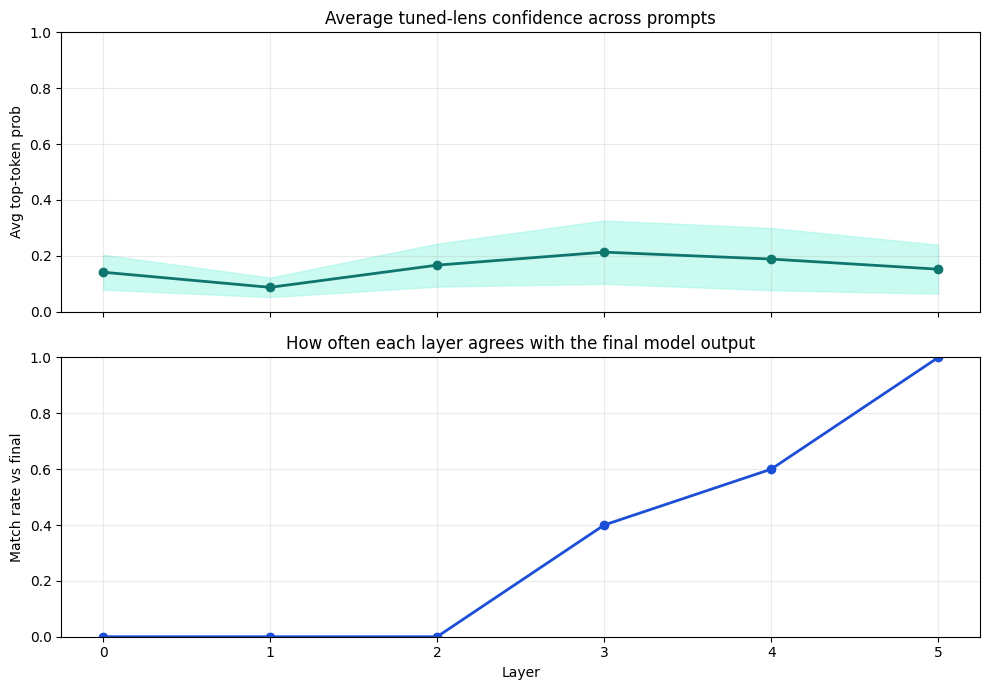

In [35]:
prompt_list = [
    "The sky is blue and the grass is",
    "The quick brown fox jumps over the lazy",
    "The capital of France is",
    "The opposite of hot is",
    "Roses are red and violets are",
]

batch_rows = []

for prompt in prompt_list:
    tokens = model.to_tokens(prompt, prepend_bos=True).to(device)
    with torch.no_grad():
        final_logits, cache = model.run_with_cache(
            tokens,
            names_filter=lambda n: n in hook_names,
        )

    final_probs = F.softmax(final_logits, dim=-1)[0, -1]
    _, final_pred_id = torch.max(final_probs, dim=-1)
    final_token = model.to_string([final_pred_id.item()]).replace("\n", "\\n")

    for layer in layers:
        hook_name = f"blocks.{layer}.hook_resid_post"
        logits = model.unembed(model.ln_final(lenses[layer](cache[hook_name])))
        probs = F.softmax(logits, dim=-1)[0, -1]
        prob, pred_id = torch.max(probs, dim=-1)
        pred_token = model.to_string([pred_id.item()]).replace("\n", "\\n")
        batch_rows.append(
            {
                "prompt": prompt,
                "layer": layer,
                "predicted_token": pred_token,
                "probability": float(prob.item()),
                "final_token": final_token,
                "matches_final": pred_token == final_token,
            }
        )

batch_df = pd.DataFrame(batch_rows)
summary_df = (
    batch_df.groupby("layer", as_index=False)
    .agg(
        mean_probability=("probability", "mean"),
        std_probability=("probability", "std"),
        match_rate=("matches_final", "mean"),
    )
)
summary_df["std_probability"] = summary_df["std_probability"].fillna(0.0)

display(Markdown("### Batch summary"))
display(
    summary_df.assign(
        mean_probability=summary_df["mean_probability"].round(3),
        std_probability=summary_df["std_probability"].round(3),
        match_rate=summary_df["match_rate"].round(3),
    ).style.hide(axis="index")
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(summary_df["layer"], summary_df["mean_probability"], marker="o", color="#0f766e", linewidth=2)
axes[0].fill_between(
    summary_df["layer"],
    summary_df["mean_probability"] - summary_df["std_probability"],
    summary_df["mean_probability"] + summary_df["std_probability"],
    color="#99f6e4",
    alpha=0.5,
)
axes[0].set_ylabel("Avg top-token prob")
axes[0].set_ylim(0, 1)
axes[0].set_title("Average tuned-lens confidence across prompts")
axes[0].grid(alpha=0.25)

axes[1].plot(summary_df["layer"], summary_df["match_rate"], marker="o", color="#1d4ed8", linewidth=2)
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Match rate vs final")
axes[1].set_ylim(0, 1)
axes[1].set_title("How often each layer agrees with the final model output")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

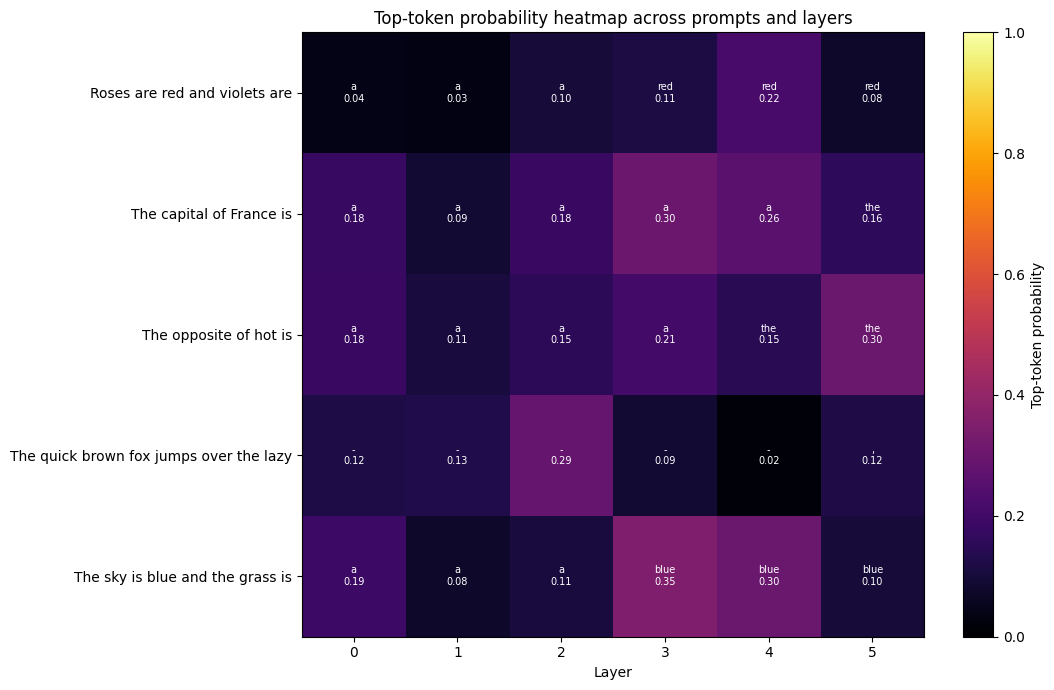

In [36]:
heatmap_df = batch_df.pivot(index="prompt", columns="layer", values="probability")
token_df = batch_df.pivot(index="prompt", columns="layer", values="predicted_token")

plt.figure(figsize=(11, 4 + 0.6 * len(heatmap_df)))
im = plt.imshow(heatmap_df.values, aspect="auto", cmap="inferno", vmin=0, vmax=1)

plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns)
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.xlabel("Layer")
plt.title("Top-token probability heatmap across prompts and layers")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        prob = heatmap_df.iloc[i, j]
        token = str(token_df.iloc[i, j]).strip()
        label = f"{token}\n{prob:.2f}"
        text_color = "white" if prob < 0.6 else "black"
        plt.text(j, i, label, ha="center", va="center", color=text_color, fontsize=7)

cbar = plt.colorbar(im)
cbar.set_label("Top-token probability")
plt.tight_layout()
plt.show()